# Продвинутое домашнее задание: Доменная адаптация энкодерной модели для семантического поиска

В рамках этого домашнего задания вы пройдете полный цикл адаптации предобученной англоязычной энкодерной модели `sentence-transformers/all-MiniLM-L6-v2` (обратите внимание: модель обучалась на английских данных, что делает задачу адаптации к русскому языку особенно показательной) для работы с русскоязычными текстами. Ваша цель - улучшить качество семантического поиска и визуально оценить изменения в пространстве эмбеддингов.

**Важное предупреждение:** Доменная адаптация - это сложный процесс, требующий тщательного подбора гиперпараметров и качественных данных. В рамках выполнения данного ДЗ в образовательных целях, скорее всего, вы получите лишь незначительное улучшение метрик поиска. Это абсолютно нормально. Главная цель - освоить методологию и пайплайн дообучения.

In [ ]:
!pip install sentence-transformers datasets faiss-cpu umap-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 31.7 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import umap
from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/tmp/ipykernel_1061/1064979242.py:10: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


## Часть 1. Визуализация пространства эмбеддингов до адаптации (20 баллов)

Перед тем как что либо улучшать, необходимо понять, с чем мы имеем дело. Мы визуализируем эмбеддинги коротких текстов, чтобы увидеть, насколько хорошо базовая модель разделяет их по смыслу.

**Задание:**
1. Загрузите датасет `ai-forever/headline-classification` (сплит `test`, возьмите первые 1000 примеров: `split="test[:1000]"`). Датасет содержит колонки `text` (заголовок новости на русском языке, строка), `label` (номер класса, число) и `label_text` (название тематики, строка: спорт, политика, экономика и т.д.). Для получения эмбеддингов используйте колонку `text`, для раскраски точек на графике - колонку `label_text`.
2. Инициализируйте базовую модель `sentence-transformers/all-MiniLM-L6-v2`.
3. Получите эмбеддинги для текстов из датасета.
4. Напишите функцию для понижения размерности эмбеддингов до 2D с использованием алгоритма UMAP.
5. Постройте scatter plot, раскрасив точки в соответствии с метками классов.

**Подсказки:**
* Обязательно зафиксируйте `random_state` в UMAP для воспроизводимости.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Размерность эмбеддингов: (1000, 384)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


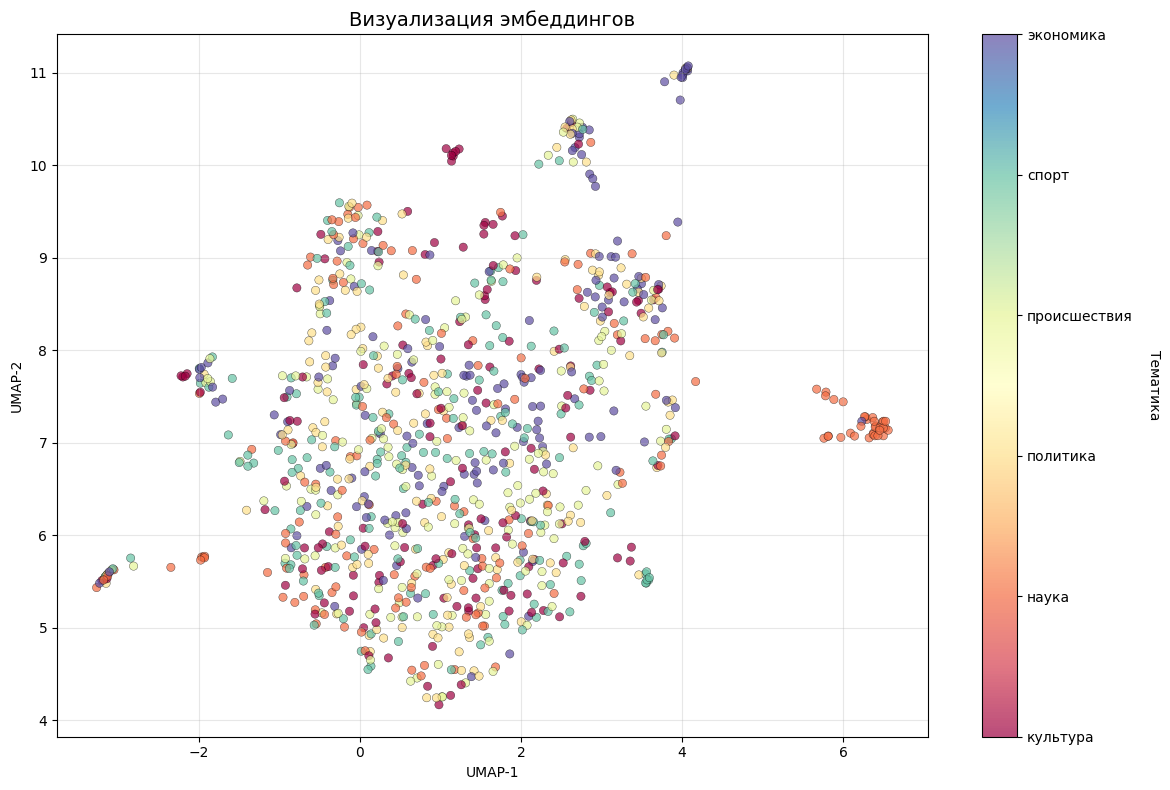

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import umap
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder


model_name = "sentence-transformers/all-MiniLM-L6-v2"
base_model = SentenceTransformer(model_name)

vis_dataset = load_dataset("ai-forever/headline-classification", split="test[:1000]")
vis_texts = vis_dataset["text"]
vis_labels = vis_dataset["label_text"]
base_embeddings = base_model.encode(
    vis_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Размерность эмбеддингов: {base_embeddings.shape}")

def plot_embeddings(embeddings, labels, title):
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    n_classes = len(le.classes_)

    reducer = umap.UMAP(
        n_components=2,
        random_state=42,
        n_neighbors=15,
        min_dist=0.1,
        metric='cosine'
    )
    embeddings_2d = reducer.fit_transform(embeddings)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels_encoded,
        cmap='Spectral',
        alpha=0.7,
        edgecolors='k',
        linewidth=0.3
    )

    cbar = plt.colorbar(scatter, ticks=range(n_classes))
    cbar.set_ticklabels(le.classes_)
    cbar.ax.set_ylabel('Тематика', rotation=270, labelpad=20)
    plt.title(title, fontsize=14)
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_embeddings(base_embeddings, vis_labels, "Визуализация эмбеддингов")

## Часть 2. Оценка базового качества поиска (25 баллов)

Теперь замерим метрики семантического поиска до доменной адаптации.

**Задание:**
1. Загрузите датасет `ai-forever/rubq-retrieval`. Этот датасет состоит из трех отдельных подмножеств, которые нужно загрузить отдельно:
   * Вопросы: подмножество (config) `queries`, сплит `queries`. Содержит колонки `_id` (строка) и `text` (строка).
   * База знаний: подмножество (config) `corpus`, сплит `corpus`. Содержит колонки `_id` (строка), `title` (строка) и `text` (строка).
   * Разметка релевантности (qrels): подмножество (config) `default`, сплит `test`. Содержит колонки `query-id` (строка), `corpus-id` (строка) и `score` (число).
2. Напишите функцию `evaluate_retrieval`, которая принимает на вход модель, вопросы (`queries`), базу знаний (`corpus`) и разметку релевантности (`qrels`), и возвращает метрики Recall@5 и Recall@10.
3. Для ускорения поиска реализуйте индекс на основе `faiss.IndexFlatIP`.
4. Замерьте и зафиксируйте базовое качество поиска.

**Подсказки и рекомендации по оценке:**
* Поскольку мы используем `faiss.IndexFlatIP` (поиск по скалярному произведению), векторы перед добавлением в индекс необходимо L2-нормализовать. Укажите `normalize_embeddings=True` при вызове метода `encode`.
* **Как считать Recall@K:**
  1. Для каждого вопроса (колонка `text` из `queries`) получите топ-K ближайших документов из базы знаний (колонка `text` из `corpus`) с помощью `faiss.Index.search`.
  2. Для этого же вопроса найдите все правильные (релевантные) документы в таблице `qrels` (строки, где колонка `query-id` совпадает с `_id` вопроса, а колонка `corpus-id` содержит ID правильных документов). Обратите внимание: у многих вопросов правильных документов несколько.
  3. Вычислите Recall@K для текущего вопроса по формуле: (количество правильных документов, попавших в ваш топ-K) / (общее количество правильных документов для этого вопроса из `qrels`).
  4. Итоговый Recall@K - это среднее арифметическое значений Recall@K по всем вопросам.
* **Маппинг идентификаторов:** Метод `faiss.Index.search` возвращает целочисленные индексы строк (от 0 до N-1). Однако в таблице `qrels` в колонке `corpus-id` лежат строковые ID документов. Важно: эти строковые ID из колонки `_id` корпуса не совпадают с порядковыми номерами строк (в нумерации есть пропуски). Поэтому простое преобразование `str(faiss_index)` даст неверные результаты. Обязательно постройте словарь-маппинг: `id_map = {i: doc_id for i, doc_id in enumerate(corpus['_id'])}` и используйте его для перевода индексов FAISS в строковые `corpus-id`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [2]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 46.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from tqdm import tqdm


eval_queries = load_dataset("ai-forever/rubq-retrieval", "queries", split="queries")
eval_corpus = load_dataset("ai-forever/rubq-retrieval", "corpus", split="corpus")
eval_qrels = load_dataset("ai-forever/rubq-retrieval", "default", split="test")

model_name = "sentence-transformers/all-MiniLM-L6-v2"
base_model = SentenceTransformer(model_name)

def evaluate_retrieval(model, queries_ds, corpus_ds, qrels_ds, top_k=[5, 10]):
    corpus_emb = model.encode(
        corpus_ds["text"],
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    dim = corpus_emb.shape[1]

    index = faiss.IndexFlatIP(dim)
    index.add(corpus_emb)

    print("Кодирование запросов...")
    query_emb = model.encode(
        queries_ds["text"],
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    id_map = {i: doc_id for i, doc_id in enumerate(corpus_ds["_id"])}

    qrels_dict = {}
    for row in qrels_ds:
        qid = row["query-id"]
        cid = row["corpus-id"]
        qrels_dict.setdefault(qid, []).append(cid)

    max_k = max(top_k)
    print(f"Поиск top-{max_k} для всех запросов...")
    distances, indices = index.search(query_emb, max_k)

    recalls = {}
    for k in top_k:
        total_recall = 0.0
        n_queries = len(queries_ds)

        for q_idx, qid in enumerate(queries_ds["_id"]):
            relevant = qrels_dict.get(qid, [])
            if not relevant:
                continue

            top_k_indices = indices[q_idx, :k]
            top_k_ids = [id_map[idx] for idx in top_k_indices]

            hits = sum(1 for doc_id in top_k_ids if doc_id in relevant)
            recall = hits / len(relevant)
            total_recall += recall

        avg_recall = total_recall / n_queries
        recalls[k] = avg_recall

    return recalls

base_metrics = evaluate_retrieval(base_model, eval_queries, eval_corpus, eval_qrels, top_k=[5, 10])
print("Базовые метрики (без адаптации):")
for k, v in base_metrics.items():
    print(f"  Recall@{k}: {v:.4f}")

README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

queries.jsonl:   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating queries split:   0%|          | 0/1692 [00:00<?, ? examples/s]

data/corpus.jsonl.zip: reconstructing file:   0%|          |  0.00B / 13.7MB            

data/corpus.jsonl.zip: downloading bytes:           |  0.00B            

...

Кодирование корпуса...


Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

Кодирование запросов...


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Поиск top-10 для всех запросов...
Базовые метрики (без адаптации):
  Recall@5: 0.0272
  Recall@10: 0.0350


## Часть 3. Доменная адаптация через TripletLoss (30 баллов)

Самая важная часть задания. Мы будем дообучать модель на русскоязычных данных с использованием функции потерь TripletLoss.

**Задание:**
1. Загрузите датасет `deepvk/ru-HNP` (сплит `train`, для ускорения можете взять первые 20000 примеров). Этот датасет содержит колонки `query` (якорь, строка), `pos` (список позитивных парафраз) и `neg` (список сложных негативных примеров).
2. Подготовьте данные для обучения. Сформируйте обучающую выборку в формате `InputExample(texts=[anchor, positive, negative])` для библиотеки `sentence-transformers`. В качестве `anchor` берите строку из колонки `query`, в качестве `positive` - первый элемент из списка в колонке `pos`, в качестве `negative` - первый элемент из списка в колонке `neg`.
3. Настройте `DataLoader` (batch_size=16 или 32) и выберите функцию потерь `TripletLoss` (доступна как `losses.TripletLoss`).
4. Запустите дообучение модели на 3 эпохи.
5. Опубликуйте модель.

**Подсказки:**
* Если вы столкнулись с нехваткой памяти, уменьшите `batch_size`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение


In [5]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from datasets import load_dataset

train_dataset = load_dataset("deepvk/ru-HNP", split="train[:20000]")

train_examples = []
for ex in train_dataset:
    anchor = ex["query"]
    positive = ex["pos"][0] if ex["pos"] else ""
    negative = ex["neg"][0] if ex["neg"] else ""
    train_examples.append(InputExample(texts=[anchor, positive, negative]))

print(f"Сформировано {len(train_examples)}")

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

model_name = "sentence-transformers/all-MiniLM-L6-v2"
finetuned_model = SentenceTransformer(model_name)

train_loss = losses.TripletLoss(model=finetuned_model)

finetuned_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=100,
    show_progress_bar=True
)
finetuned_model.save("finetuned_model_all-MiniLM-L6-v2")
print("Готов вроде")

README.md:   0%|          | 0.00/5.82k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B / 86.9MB            

train.parquet: downloading bytes:           |  0.00B            

val.parquet: reconstructing file:   0%|          |  0.00B /  538kB            

val.parquet: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,4.228315
1000,3.976144
1500,3.937987
2000,3.904335
2500,3.910816
3000,3.881619
3500,3.885958


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Готов вроде


## Часть 4. Оценка качества после адаптации (25 баллов)

Проверим, дало ли наше дообучение результат.

**Задание:**
1. Снова вызовите функцию `evaluate_retrieval` на датасете `ai-forever/rubq-retrieval`, но теперь передайте в неё дообученную модель.
2. Сравните метрики Recall@K до и после дообучения. Сделайте письменный вывод.
3. Повторите процесс из Части 1: визуализируйте эмбеддинги датасета `ai-forever/headline-classification` с помощью дообученной модели. Сравните два графика. Стали ли кластеры более разделимыми?

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [11]:
finetuned_model = SentenceTransformer("finetuned_model_all-MiniLM-L6-v2")

finetuned_metrics = evaluate_retrieval(finetuned_model, eval_queries, eval_corpus, eval_qrels, top_k=[5, 10])
print("Метрики после дообучения:")
for k, v in finetuned_metrics.items():
    print(f"  Recall@{k}: {v:.4f}")

print("\nСравнение с базовой моделью:")
for k in [5, 10]:
    delta = finetuned_metrics[k] - base_metrics[k]
    print(f"  Recall@{k}: базовый = {base_metrics[k]}  и  дообученный = {finetuned_metrics[k]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Кодирование корпуса моделью SentenceTransformer...


Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

Кодирование запросов...


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Метрики после дообучения:
  Recall@5: 0.0031
  Recall@10: 0.0031

Сравнение с базовой моделью:
  Recall@5: базовый = 0.02719379714060565  и  дообученный = 0.0031
  Recall@10: базовый = 0.035024766407745135  и  дообученный = 0.0031


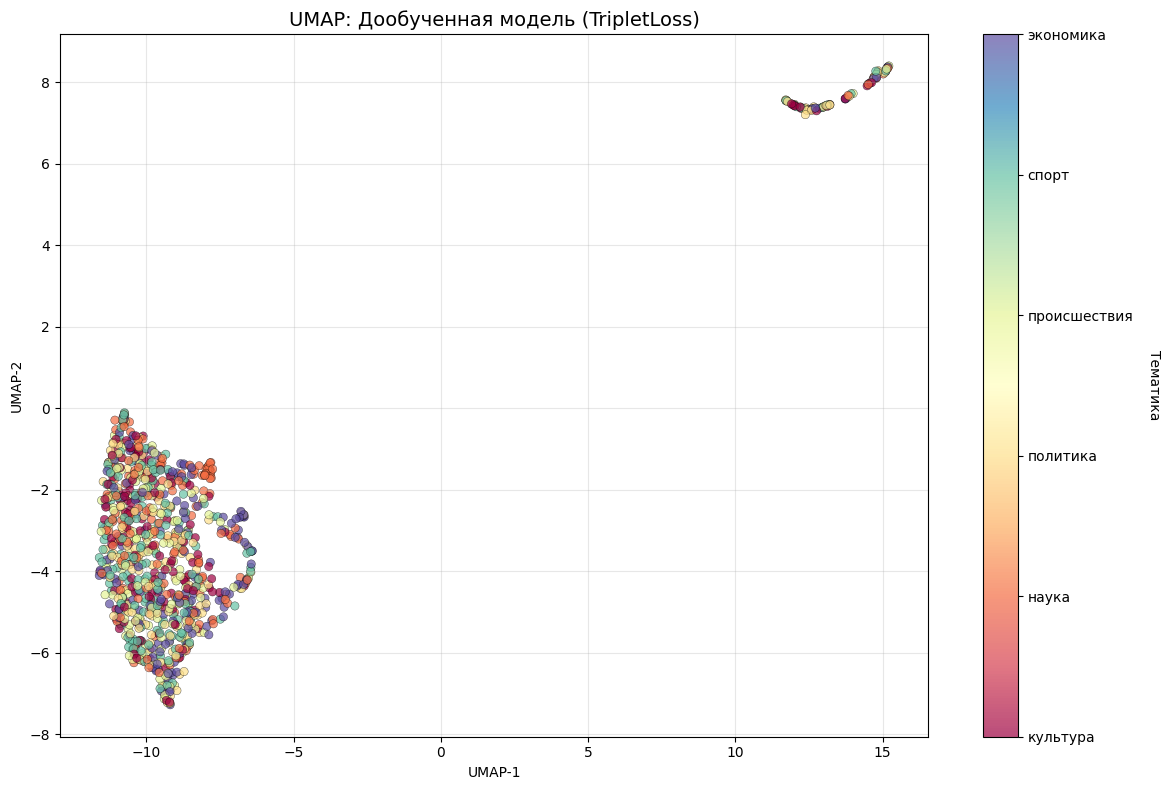

In [9]:
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import LabelEncoder

def plot_embeddings(embeddings, labels, title, save_path=None):
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    n_classes = len(le.classes_)

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                          c=labels_encoded, cmap='Spectral', alpha=0.7,
                          edgecolors='k', linewidth=0.3)
    cbar = plt.colorbar(scatter, ticks=range(n_classes))
    cbar.set_ticklabels(le.classes_)
    cbar.ax.set_ylabel('Тематика', rotation=270, labelpad=20)
    plt.title(title, fontsize=14)
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_embeddings(finetuned_embeddings, vis_labels, "UMAP: Дообученная модель (TripletLoss)")

### Выводы

Напишите краткий вывод по результатам эксперимента. Улучшились ли метрики? Как изменилась визуализация кластеров? Почему доменная адаптация на парафразах могла дать именно такой результат на задаче QA-поиска?

**Ваш ответ:**

Адаптация all-MiniLM-L6-v2 на русском привела к падению метрик с 0,027/0,035 до 0,0031. Модель перестала различать нормально документы. На визуализации это хорошо видно. Классы просто сгруппировалист. Возможно недостаточный размер данных, много шума. Также эта модель не оптимизированна под руский, так что возможно результат - это какое-то следствие адаптация модели русскому.